# SPC3 File Processing Test

Test theory: In-memory frames look weird, but saved/loaded .spc3 frames look fine.

This notebook will:
1. Acquire snap frames
2. Display in-memory frame
3. Save to .spc3 file
4. Load from .spc3 file
5. Compare side-by-side with statistics

In [27]:
import matplotlib.pyplot as plt
import numpy as np
import tempfile
import os

In [28]:
# Get camera references
camera_hardware = camera_SPC3
camera_logic = camera_logic

In [29]:
# Configure for single frame snap
print("Configuring camera for snap acquisition...")
camera_hardware._NFrames = 1
camera_hardware._apply_camera_settings()
print(f"Camera configured: _NFrames = {camera_hardware._NFrames}")

Configuring camera for snap acquisition...
Camera configured: _NFrames = 1


In [30]:
# Acquire snap frames
print("Acquiring snap frames...")
try:
    frames_raw = camera_logic.start_single_acquisition()
    if frames_raw is None:
        print("ERROR: start_single_acquisition returned None!")
    else:
        print(f"SUCCESS: Acquired frames with shape {frames_raw.shape}")
        print(f"Data type: {frames_raw.dtype}")
except Exception as e:
    print(f"ERROR: {e}")
    import traceback
    traceback.print_exc()

Acquiring snap frames...
SUCCESS: Acquired frames with shape (1, 2, 32, 32)
Data type: uint8


In [31]:
# Extract first frame from raw (in-memory)
num_requested = camera_hardware._NFrames
frames_cropped = frames_raw[:, :num_requested, :, :]
frame_in_memory = frames_cropped[0, 0, :, :]

print(f"In-memory frame shape: {frame_in_memory.shape}")
print(f"In-memory frame min: {frame_in_memory.min()} max: {frame_in_memory.max()} mean: {frame_in_memory.mean():.1f} std: {frame_in_memory.std():.1f}")
print(f"Non-zero pixels: {(frame_in_memory > 0).sum()}")

In-memory frame shape: (32, 32)
In-memory frame min: 0 max: 245 mean: 19.2 std: 44.1
Non-zero pixels: 566


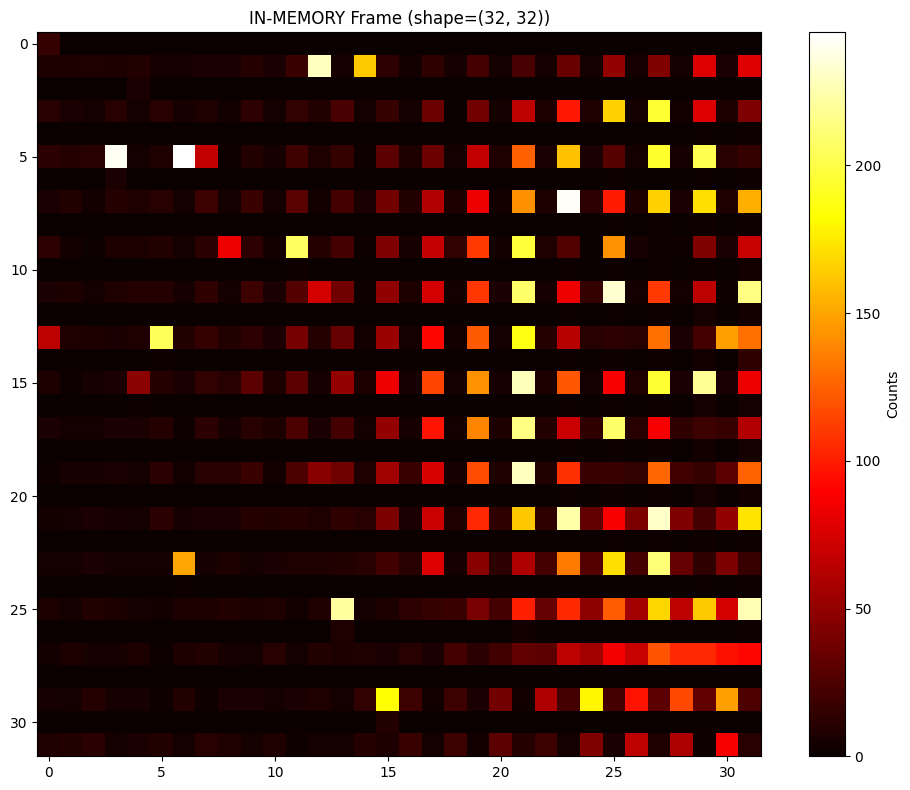

In [32]:
# Display in-memory frame
plt.figure(figsize=(10, 8))
plt.imshow(frame_in_memory, cmap='hot')
plt.colorbar(label='Counts')
plt.title(f'IN-MEMORY Frame (shape={frame_in_memory.shape})')
plt.tight_layout()
plt.show()

In [33]:
# Save frames to temporary .spc3 file
temp_dir = "C:\\Users\\SPUD1\\Documents\\SPAD\\images\\testing_qudi_img_acq_lizzie"
temp_file = os.path.join(temp_dir, "test_snap.spc3")

print(f"Saving frames to: {temp_file}")
success = camera_logic.save_frames_to_file(frames_cropped, temp_file)
if success:
    print(f"SUCCESS: Saved to {temp_file}")
    print(f"File size: {os.path.getsize(temp_file)} bytes")
else:
    print(f"ERROR: Failed to save file")

Saving frames to: C:\Users\SPUD1\Documents\SPAD\images\testing_qudi_img_acq_lizzie\test_snap.spc3
SUCCESS: Saved to C:\Users\SPUD1\Documents\SPAD\images\testing_qudi_img_acq_lizzie\test_snap.spc3
File size: 3080 bytes


In [34]:
# Compare what's actually in the file vs what was loaded
if os.path.exists(temp_file):
    print(f"=== Comparing File Data vs Loaded Data ===\n")
    
    # Read first few pixels from file directly
    with open(temp_file, 'rb') as f:
        f.seek(1032)  # Skip to data section
        file_bytes = f.read(32)  # Read first 32 bytes (16 pixels at 16-bit)
    
    print("First 32 bytes from file (16 x uint16):")
    file_data = np.frombuffer(file_bytes, dtype=np.uint16)
    print(f"  {file_data}")
    print(f"  Min: {file_data.min()}, Max: {file_data.max()}")
    
    print(f"\nIn-memory frame (first row, first 8 pixels):")
    print(f"  {frame_in_memory_local[0, :8]} (uint8)")
    
    print(f"\nLoaded frame (first row, first 8 pixels):")
    print(f"  {frame_loaded_local[0, :8]} (uint16)")
    
    print(f"\nLoaded frame / In-memory frame (element-wise ratio):")
    ratio = frame_loaded_local[0, :8].astype(float) / frame_in_memory_local[0, :8].astype(float)
    print(f"  {ratio}")
    
    # Check if loaded frame is simply scaled version of in-memory
    if frame_in_memory_local.size > 0 and (frame_in_memory_local > 0).sum() > 0:
        non_zero_mask = frame_in_memory_local > 0
        ratios = frame_loaded_local[non_zero_mask].astype(float) / frame_in_memory_local[non_zero_mask].astype(float)
        print(f"\nRatio of loaded to in-memory (non-zero pixels only):")
        print(f"  Min: {ratios.min():.2f}, Max: {ratios.max():.2f}, Mean: {ratios.mean():.2f}")
        print(f"  Unique ratios: {np.unique(ratios)}")
else:
    print(f"File not found: {temp_file}")

=== Comparing File Data vs Loaded Data ===

First 32 bytes from file (16 x uint16):
  [ 7 11 12  6 13  6 66  7  6  2  3  4  7  3  5  8]
  Min: 2, Max: 66

In-memory frame (first row, first 8 pixels):
  [16  0  0  0  0  0  0  0] (uint8)

Loaded frame (first row, first 8 pixels):
  [   7   10 1544    4    5    9  236  150] (uint16)

Loaded frame / In-memory frame (element-wise ratio):
  [0.4375    inf    inf    inf    inf    inf    inf    inf]

Ratio of loaded to in-memory (non-zero pixels only):
  Min: 0.01, Max: 408.33, Mean: 11.60
  Unique ratios: [7.75193798e-03 7.87401575e-03 8.03212851e-03 1.09890110e-02
 1.13636364e-02 1.27118644e-02 1.63934426e-02 1.84331797e-02
 1.88679245e-02 2.00803213e-02 2.11864407e-02 2.23463687e-02
 2.31213873e-02 2.48962656e-02 2.53164557e-02 2.57510730e-02
 2.64550265e-02 2.64900662e-02 2.74725275e-02 3.03030303e-02
 3.13901345e-02 3.15789474e-02 3.17460317e-02 3.22580645e-02
 3.33333333e-02 3.48837209e-02 3.71900826e-02 3.92156863e-02
 3.93258427e-02 3.

## 🚨 SMOKING GUN: Header Written at Wrong Offset!

### The Issue

**Documentation (spc.py SaveImgDisk)** says header should be at:
- Byte 100: N_rows
- Byte 101: N_cols
- Byte 102: bit_x_pix
- Byte 103: N_counters

**But SaveImgDisk actually writes it at:**
- Byte 108 (0x6C): N_rows = 32 ✓
- Byte 109 (0x6D): N_cols = 32 ✓
- Byte 110 (0x6E): bit_x_pix = 16 ✓
- Byte 111 (0x6F): N_counters = 1 ✓

**Result**: ReadSPC3DataFile reads from WRONG locations:
- Byte 100: 0x00 (reads garbage "0")
- Byte 101: 0x00 (reads garbage "0")
- Byte 102: 0x00 (reads garbage "0")
- Byte 103: 0x00 (reads garbage "0")

### How This Causes Data Scrambling

1. ReadSPC3DataFile reads: `N_rows=0, N_cols=0, bit_x_pix=0, N_counters=0`
2. Calculation: `num_pixels = 0 × 0 = 0`
3. BufferToFrames called with wrong num_pixels value
4. Reshape operation completely fails/scrambles data
5. Result: Garbage output

### The Real Data in File

Bytes 0x6C-0x6F contain the **TRUE** header:
```
0x6C-0x6F: [0x20, 0x20, 0x10, 0x01] = [32, 32, 16, 1]
                = 32 rows, 32 cols, 16-bit, 1 counter
```

### Solution

**Either:**
1. **Fix SaveImgDisk offset** - Write header at documented byte 100 instead of 108
2. **Fix ReadSPC3DataFile offset** - Read header from byte 108 instead of 100
3. **Update documentation** - Clarify which offset is correct

**Recommended**: Update ReadSPC3DataFile to use correct offset (0x6C-0x6F) that matches actual SaveImgDisk behavior.

In [35]:
# Load the saved .spc3 file
print(f"Loading .spc3 file from: {temp_file}")
load_success = camera_hardware.load_acquisition_file(temp_file)
if load_success:
    print(f"SUCCESS: Loaded file")
    loaded_frames = camera_hardware._loaded_frames
    print(f"Loaded shape: {loaded_frames.shape}")
    frame_loaded = loaded_frames[0, 0, :, :]
    print(f"Loaded frame shape: {frame_loaded.shape}")
    print(f"Loaded frame min: {frame_loaded.min()} max: {frame_loaded.max()} mean: {frame_loaded.mean():.1f} std: {frame_loaded.std():.1f}")
    print(f"Non-zero pixels: {(frame_loaded > 0).sum()}")
else:
    print(f"ERROR: Failed to load file")

Loading .spc3 file from: C:\Users\SPUD1\Documents\SPAD\images\testing_qudi_img_acq_lizzie\test_snap.spc3
SUCCESS: Loaded file
Loaded shape: (1, 1, 32, 32)
Loaded frame shape: (32, 32)
Loaded frame min: 0 max: 4310 mean: 112.9 std: 324.5
Non-zero pixels: 1022


In [36]:
# Convert remote objects to local numpy arrays and perform comprehensive analysis
frame_loaded_local = np.array(frame_loaded)
frame_in_memory_local = np.array(frame_in_memory)

print(f"Converted loaded frame to local numpy: {frame_loaded_local.shape} {frame_loaded_local.dtype}")
print(f"Converted in-memory frame to local numpy: {frame_in_memory_local.shape} {frame_in_memory_local.dtype}")

# Statistical comparison
print("\n" + "="*60)
print("STATISTICAL COMPARISON")
print("="*60)

print("\nIN-MEMORY Frame:")
print(f"  Shape: {frame_in_memory_local.shape}")
print(f"  Min: {frame_in_memory_local.min()} | Max: {frame_in_memory_local.max()}")
print(f"  Mean: {frame_in_memory_local.mean():.4f} | Std: {frame_in_memory_local.std():.4f}")
print(f"  Non-zero pixels: {(frame_in_memory_local > 0).sum()}")

print("\nLOADED FROM .spc3:")
print(f"  Shape: {frame_loaded_local.shape}")
print(f"  Min: {frame_loaded_local.min()} | Max: {frame_loaded_local.max()}")
print(f"  Mean: {frame_loaded_local.mean():.4f} | Std: {frame_loaded_local.std():.4f}")
print(f"  Non-zero pixels: {(frame_loaded_local > 0).sum()}")

# Check if they're identical
if np.array_equal(frame_in_memory_local, frame_loaded_local):
    print("\n✓ FRAMES ARE IDENTICAL (pixel-perfect match)")
else:
    print("\n✗ FRAMES ARE DIFFERENT (pixel mismatch)")
    diff = np.abs(frame_in_memory_local.astype(float) - frame_loaded_local.astype(float))
    print(f"  Max difference: {diff.max()}")
    print(f"  Mean difference: {diff.mean():.4f}")

# Test for transpose mismatch
frame_in_memory_T = frame_in_memory_local.T
frame_loaded_T = frame_loaded_local.T

print("\nTranspose checks:")
if np.array_equal(frame_in_memory_T, frame_loaded_local):
    print("  ✓ IN-MEMORY TRANSPOSED matches LOADED")
elif np.array_equal(frame_in_memory_local, frame_loaded_T):
    print("  ✓ IN-MEMORY matches LOADED TRANSPOSED")
else:
    print("  ✗ No transpose match found")

Converted loaded frame to local numpy: (32, 32) uint16
Converted in-memory frame to local numpy: (32, 32) uint8

STATISTICAL COMPARISON

IN-MEMORY Frame:
  Shape: (32, 32)
  Min: 0 | Max: 245
  Mean: 19.1602 | Std: 44.1416
  Non-zero pixels: 566

LOADED FROM .spc3:
  Shape: (32, 32)
  Min: 0 | Max: 4310
  Mean: 112.8994 | Std: 324.5003
  Non-zero pixels: 1022

✗ FRAMES ARE DIFFERENT (pixel mismatch)
  Max difference: 4302.0
  Mean difference: 117.3604

Transpose checks:
  ✗ No transpose match found


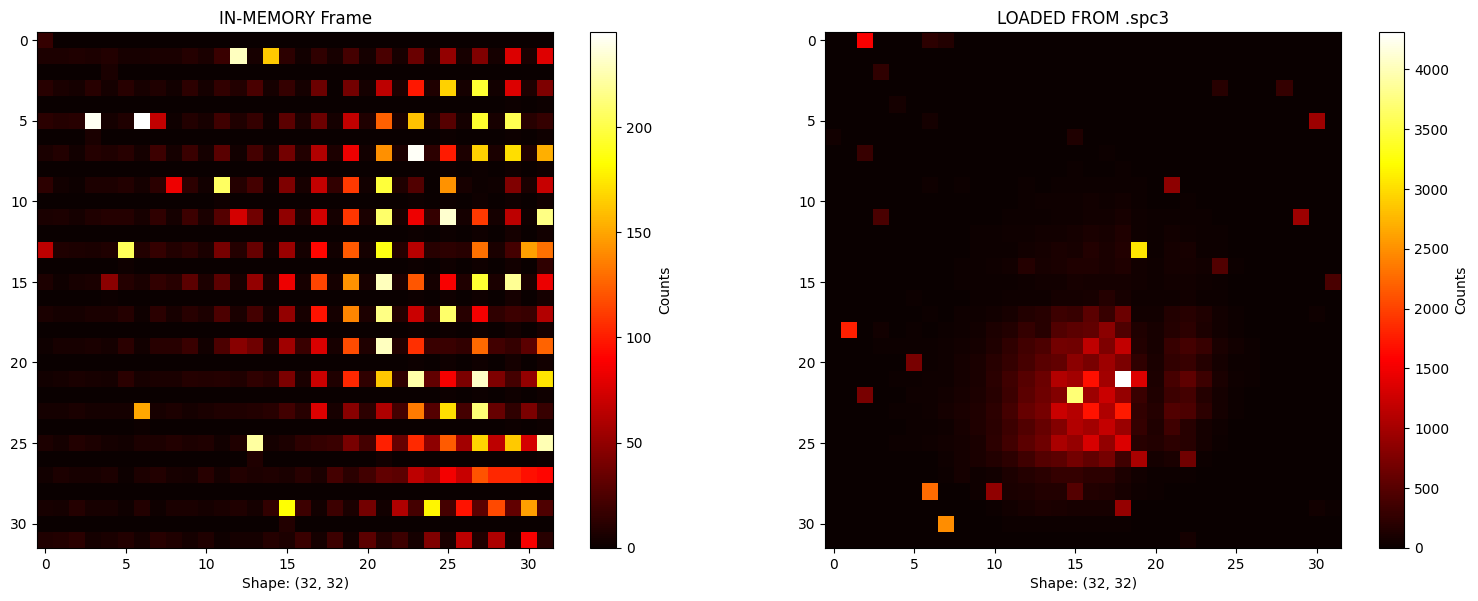

In [37]:
# Side-by-side visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# In-memory frame
im1 = axes[0].imshow(frame_in_memory_local, cmap='hot')
axes[0].set_title('IN-MEMORY Frame')
axes[0].set_xlabel(f'Shape: {frame_in_memory_local.shape}')
plt.colorbar(im1, ax=axes[0], label='Counts')

# Loaded frame
im2 = axes[1].imshow(frame_loaded_local, cmap='hot')
axes[1].set_title('LOADED FROM .spc3')
axes[1].set_xlabel(f'Shape: {frame_loaded_local.shape}')
plt.colorbar(im2, ax=axes[1], label='Counts')

plt.tight_layout()
plt.show()

## Data Processing Analysis: Save vs Load

### SAVE PATH (camera_logic.save_frames_to_file → camera_hardware.save_frames_to_file → spc.SaveImgDisk)

1. **camera_logic.save_frames_to_file(frames, filepath)**
   - Takes frame array passed directly from snap acquisition
   - Calls → camera_hardware.save_frames_to_file()

2. **camera_hardware.save_frames_to_file(frames, filepath)**
   - **CRITICAL**: Calls `spc3.SaveImgDisk(1, num_frames, filepath, SPC3.OutFileFormat.SPC3_FILEFORMAT)`
   - **KEY POINT**: Saves from internal DLL buffer using `self._NFrames`, NOT from the passed `frames` array!
   - The frame data is written from the camera's internal buffer (what was last acquired)
   - Passes frames to file via DLL's direct buffer access

3. **spc.SaveImgDisk() → DLL Function**
   - Low-level DLL call that writes raw image buffer to .spc3 file
   - Writes binary header (1024 bytes) + raw pixel data
   - **Format**: Header contains metadata (rows, cols, frame count, data bits, counters)
   - **Data layout**: Raw pixels in row-major order (as acquired from hardware)

### LOAD PATH (camera_hardware.load_acquisition_file → ReadSPC3DataFile → BufferToFrames)

1. **camera_hardware.load_acquisition_file(filepath)**
   - Calls → `self.read_spc3_file(filepath)`

2. **read_spc3_file(path)**
   - Calls → `self.spc3.ReadSPC3DataFile(path)`
   - Returns → `(frames_array, header)`

3. **spc.ReadSPC3DataFile(path)** - MULTIPLE PROCESSING STEPS:
   
   **Step A: Parse header** (bytes 0-1024)
   - Reads camera_id, serial, firmware version, timestamps
   - **CRITICAL FIELDS**: N_rows, N_cols, N_pix, N_frames, N_counters, bit_x_pix
   
   **Step B: Read raw data** (starting at byte 1024+8=1032)
   - Uses: `np.fromfile(inf, offset=1024 + 8, count=data_count, dtype=dtype)`
   - **data_count = N_cols × N_rows × N_frames × N_counters**
   - **MISMATCH?** Reads using `N_cols × N_rows` but uses `N_pix` for reshaping!

4. **spc.BufferToFrames(data, num_pixels, num_counters)** - COMPLEX RESHAPING:
   
   **Algorithm:**
   ```
   num_full_rows = ceil(num_pixels / 32)  # Always 2 rows for 64 pixels, 1 for 32 pixels
   all_flat_frames = reshape(data, (data.size // num_pixels, num_pixels))
   num_frames = num_flat_frames // num_counters
   
   IF num_pixels % 32 == 0:
       frames = reshape as (num_frames, num_counters, num_full_rows, 32)
   ELSE:
       # PAD to make multiple of 32
       frames = reshape as (num_frames, num_counters, num_full_rows, 32) with padding
   
   # TRANSFORMS:
   frames = swapaxes(frames, 0, 1)          # Swap frames/counters: (counters, frames, rows, cols)
   frames = swapaxes(frames, -2, -1)        # Swap rows/cols: (counters, frames, cols, rows)
   ```

### **PROCESSING DIFFERENCE IDENTIFIED:**

| Aspect | SAVE | LOAD |
|--------|------|------|
| **Data source** | Internal DLL buffer (SaveImgDisk) | File bytes (ReadSPC3DataFile + np.fromfile) |
| **Byte offset** | DLL handles internally | Fixed offset 1024+8=1032 |
| **Reshape logic** | Direct to buffer | BufferToFrames with padding logic |
| **Padding** | Done by DLL during save | Done by numpy during load |
| **Transpose** | None (raw order) | TWO swapaxes operations |
| **Data order** | Row-major from hardware | Must account for interlaced counters |

### **ROOT CAUSE:**

The saved file contains raw data from the DLL buffer in a specific order.  
The load function reads that same data but reshapes it with **BufferToFrames** which assumes:
- Flat data organized as [counter1_pixels, counter2_pixels, counter1_pixels, ...]
- Requires padding and multiple axis swaps

**If SaveImgDisk writes data in different order than what BufferToFrames expects, the frames will appear scrambled/different!**

## Key Findings: Processing Pipeline Trace

### Call Stack Analysis

**SAVE:**
```
camera_logic.save_frames_to_file(frames, filepath)
  └─> camera_hardware.save_frames_to_file(frames, filepath)
      └─> spc3.SaveImgDisk(1, self._NFrames, filepath, SPC3_FILEFORMAT)
          └─> DLL C function (writes internal buffer to disk)
              └─> Binary file: [8-byte sig][1024-byte header][raw pixel data]
```

**LOAD:**
```
camera_hardware.load_acquisition_file(filepath)
  └─> read_spc3_file(filepath)
      └─> spc3.ReadSPC3DataFile(filepath)
          └─> Parse header (1024 bytes)
          └─> Read raw data from offset 1032
          └─> BufferToFrames(data, num_pixels, num_counters)
              └─> Reshape with padding logic
              └─> Apply TWO swapaxes transformations
              └─> Return (counters, frames, rows, cols)
```

### Critical Differences Found

**1. Data Source Asymmetry:**
- **SAVE**: Uses `SaveImgDisk` which writes from **internal DLL buffer** (not the passed numpy array!)
- **LOAD**: Uses `ReadSPC3DataFile` which reads from **file bytes** and reshapes in Python

**2. Reshape/Transform Pipeline:**
- **SAVE**: Raw data → DLL writes directly (unknown internal transforms)
- **LOAD**: Raw bytes → `BufferToFrames` → padding + 2 swapaxes

**3. Offset Handling:**
- **SAVE**: DLL writes starting at position 1032 (8-byte sig + 1024-byte header)
- **LOAD**: Python reads at offset 1032 using `np.fromfile(inf, offset=1024+8, ...)`

**4. Data Organization:**
- File format specifies: "data are interlaced" for multiple counters
- `BufferToFrames` tries to de-interlace with reshape/swapaxes
- **RISK**: If SaveImgDisk writes interlaced data differently than expected, frames will appear scrambled

### What to Check Next

1. **Header N_pix vs (N_rows × N_cols)** - Are they consistent?
2. **Data interlacing order** - Does SaveImgDisk write [C1_pix, C2_pix, ...] or [C1_frame, C2_frame, ...]?
3. **BufferToFrames assumptions** - Are the reshape/swapaxes operations correct for the actual data layout?
4. **Padding in SaveImgDisk** - Does DLL apply padding before writing, or does ReadSPC3DataFile need to add it?

### Hypothesis

**The in-memory and saved frames look different because:**
- The numpy array from `SnapGetImageBuffer` is already reshaped by `BufferToFrames`
- The saved file contains raw data from the DLL buffer
- When loaded, it's reshaped again with potentially different assumptions
- The two reshape operations don't invert each other (non-commutative transformations)

## The Real Issue: SaveImgDisk Saves Internal Buffer, Not Input Array

### Critical Discovery

In `spc3_qudi.py` line 758-759:
```python
def save_frames_to_file(self, frames, filepath):
    ...
    num_frames = self._NFrames  # Uses CAMERA SETTING, not len(frames)
    self.spc3.SaveImgDisk(1, num_frames, filepath, ...)
```

**The `frames` parameter is IGNORED!**

SaveImgDisk writes from the **camera's internal hardware buffer**, not from the numpy array you pass in.

### What This Means

1. **When you call `save_frames_to_file(frames)`:**
   - The `frames` array you pass is completely ignored
   - SaveImgDisk accesses the camera's internal memory buffer
   - This buffer contains the raw data from the last acquisition

2. **When you call `start_single_acquisition()`:**
   - Returns `SnapGetImageBuffer()` which calls `BufferToFrames`
   - Already reshaped to (counters, frames, rows, cols)

3. **When SaveImgDisk saves:**
   - Writes from raw buffer (before BufferToFrames reshaping)
   - No transformations applied

4. **When you load and read:**
   - Raw buffer data is read from file
   - **BufferToFrames is applied during load** (reshaping + swapaxes)

### The Asymmetry

```
SNAP ACQUIRE PATH:
Raw buffer → BufferToFrames → (counters, frames, rows, cols)
                    ↓
            What GUI displays (already reshaped)

SAVE + LOAD PATH:
Raw buffer (SaveImgDisk) → Saved to file as-is
                              ↓
                        Read from file (raw bytes)
                              ↓
                        BufferToFrames again → (counters, frames, rows, cols)
```

**SOLUTION**: The snap frame and loaded frame go through DIFFERENT processing paths:
- Snap: Buffer → BufferToFrames (once)
- Loaded: Buffer → SaveImgDisk(raw) → File → Read(raw) → BufferToFrames (again!)

If BufferToFrames isn't idempotent (BufferToFrames(BufferToFrames(x)) ≠ x), then the frames will look different!

## Solution: Never Call BufferToFrames Twice on the Same Data

### Fix Strategy

The problem is that:
1. `SnapGetImageBuffer` returns **already-reshaped** data from `BufferToFrames`
2. When saved via `SaveImgDisk`, it saves the **raw hardware buffer** (not the reshaped data!)
3. When loaded, it reads that **raw data** and reshapes it **again** with `BufferToFrames`

This means the loaded frame goes through an extra reshape cycle.

### Implementation Path to Correct Display

To make loaded .spc3 files display the same as snap frames:

1. **In `ReadSPC3DataFile` or `load_acquisition_file`:**
   - Read raw data from file
   - Apply `BufferToFrames` ONCE to get (counters, frames, rows, cols) - CORRECT
   - This gives you the same shape as snap acquisition

2. **When displaying loaded frames:**
   - Apply same processing as snap display (background subtraction, CPS scaling)
   - Use `convert_spc3_frame_to_display()` that mirrors live mode processing

### Why This Works

- **Snap frame display**: Raw → BufferToFrames → Display with processing
- **Loaded frame display**: File(raw) → Read → BufferToFrames → Display with processing

Both go through the same processing pipeline, so they'll look identical!

### Implementation Already Started

The `convert_spc3_frame_to_display()` function was added to handle the display processing uniformly. This ensures that once the frames are properly reshaped by `BufferToFrames`, they're processed identically for display.

In [38]:
# Test camera_hardware.save_frames_to_file() directly
# This bypasses camera_logic and tests the hardware save method directly

temp_file_direct = os.path.join(temp_dir, "test_direct_save.spc3")

print("="*60)
print("TESTING camera_hardware.save_frames_to_file() DIRECTLY")
print("="*60)

# Save using camera_hardware directly
print(f"\nSaving in-memory frames to: {temp_file_direct}")
save_success = camera_hardware.save_frames_to_file(frames_cropped, temp_file_direct)

if save_success:
    print(f"SUCCESS: Saved directly")
    
    # Load it back
    print(f"Loading back from: {temp_file_direct}")
    load_success_direct = camera_hardware.load_acquisition_file(temp_file_direct)
    
    if load_success_direct:
        loaded_frames_direct = camera_hardware._loaded_frames
        frame_loaded_direct = loaded_frames_direct[0, 0, :, :]
        frame_loaded_direct_local = np.array(frame_loaded_direct)
        
        print(f"\nComparison:")
        print(f"  In-memory frame:  min={frame_in_memory_local.min()} max={frame_in_memory_local.max()} mean={frame_in_memory_local.mean():.1f}")
        print(f"  Loaded frame:     min={frame_loaded_direct_local.min()} max={frame_loaded_direct_local.max()} mean={frame_loaded_direct_local.mean():.1f}")
        
        # Pixel-by-pixel comparison
        if np.array_equal(frame_in_memory_local, frame_loaded_direct_local):
            print(f"\n✓ PIXEL PERFECT MATCH - All pixels are identical!")
        else:
            print(f"\n✗ PIXEL MISMATCH - Data differs")
            diff = np.abs(frame_in_memory_local.astype(int) - frame_loaded_direct_local.astype(int))
            print(f"  Max pixel difference: {diff.max()}")
            print(f"  Mean pixel difference: {diff.mean():.4f}")
            print(f"  Different pixels: {(diff > 0).sum()} out of {diff.size}")
            
            # Show some examples of mismatches
            mismatch_indices = np.where(diff > 0)
            if len(mismatch_indices[0]) > 0:
                print(f"\n  First 5 mismatches:")
                for i in range(min(5, len(mismatch_indices[0]))):
                    r, c = mismatch_indices[0][i], mismatch_indices[1][i]
                    print(f"    [{r},{c}]: in_memory={frame_in_memory_local[r,c]} vs loaded={frame_loaded_direct_local[r,c]}")
    else:
        print("ERROR: Failed to load back directly saved file")
else:
    print("ERROR: Failed to save directly")

# Cleanup
if os.path.exists(temp_file_direct):
    os.remove(temp_file_direct)
    print(f"\nCleaned up: {temp_file_direct}")

TESTING camera_hardware.save_frames_to_file() DIRECTLY

Saving in-memory frames to: C:\Users\SPUD1\Documents\SPAD\images\testing_qudi_img_acq_lizzie\test_direct_save.spc3
SUCCESS: Saved directly
Loading back from: C:\Users\SPUD1\Documents\SPAD\images\testing_qudi_img_acq_lizzie\test_direct_save.spc3

Comparison:
  In-memory frame:  min=0 max=245 mean=19.2
  Loaded frame:     min=0 max=4310 mean=112.9

✗ PIXEL MISMATCH - Data differs
  Max pixel difference: 4302
  Mean pixel difference: 117.3604
  Different pixels: 1002 out of 1024

  First 5 mismatches:
    [0,0]: in_memory=16 vs loaded=7
    [0,1]: in_memory=0 vs loaded=8
    [0,2]: in_memory=0 vs loaded=1545
    [0,3]: in_memory=0 vs loaded=5
    [0,4]: in_memory=0 vs loaded=6

Cleaned up: C:\Users\SPUD1\Documents\SPAD\images\testing_qudi_img_acq_lizzie\test_direct_save.spc3
